In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Klasörleri oluştur
paths = ["models_advanced_eset", "plots_advanced_eset", "results"]
for p in paths:
    os.makedirs(p, exist_ok=True)

    # ADIM A: Veri yükle
df = pd.read_csv('/content/drive/MyDrive/veri-madenciligi-projesi/merged_with_lags.csv')
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# ADIM B: X ve target'ları hazırla
targets = ["Target_1d", "Target_7d", "Target_30d", "Target_365d"]
X = df.drop(columns=["Date"] + targets)
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan).ffill().bfill()

# ADIM C: Zaman bazlı Split (%80 Train, %20 Test)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
dates_test = df["Date"].iloc[split_idx:].reset_index(drop=True)

In [ ]:
import os

plot_directory = 'plots_advanced_eset'
print(f"Listing contents of directory: {plot_directory}")
if os.path.exists(plot_directory) and os.path.isdir(plot_directory):
    for file in os.listdir(plot_directory):
        print(file)
else:
    print(f"Directory not found: {plot_directory}")

Listing contents of directory: plots_advanced_eset


In [ ]:
from IPython.display import Image, display
import os

plot_files = [
    'plots_advanced_eset/Target_1d_predictions.png',
    'plots_advanced_eset/Target_7d_predictions.png',
    'plots_advanced_eset/Target_30d_predictions.png',
    'plots_advanced_eset/Target_365d_predictions.png'
]

for plot_file in plot_files:
    if os.path.exists(plot_file):
        print(f"Displaying {plot_file}:")
        display(Image(filename=plot_file))
    else:
        print(f"Plot file not found: {plot_file}")

Plot file not found: plots_advanced_eset/Target_1d_predictions.png
Plot file not found: plots_advanced_eset/Target_7d_predictions.png
Plot file not found: plots_advanced_eset/Target_30d_predictions.png
Plot file not found: plots_advanced_eset/Target_365d_predictions.png


In [24]:
# ADIM D: Hedef değişkenleri hazırla ve Modelleri Eğit
all_results = {}

for target_name in targets:
    print(f"\nEğitim başlıyor: {target_name}")

    y = df[target_name]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    # PCA uygulaması
    pca = PCA(n_components=0.95) # %95 varyansı koru
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # ElasticNet Modeli
    elastic_net_params = {
        'alpha': [0.1, 1.0, 10.0],
        'l1_ratio': [0.1, 0.5, 0.9]
    }
    elastic_net_model = GridSearchCV(ElasticNet(random_state=42), elastic_net_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    elastic_net_model.fit(X_train_pca, y_train)
    elastic_net_best = elastic_net_model.best_estimator_
    y_pred_elastic_net = elastic_net_best.predict(X_test_pca)

    # SVR Modeli
    svr_params = {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto']
    }
    svr_model = GridSearchCV(SVR(), svr_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    svr_model.fit(X_train_pca, y_train)
    svr_best = svr_model.best_estimator_
    y_pred_svr = svr_best.predict(X_test_pca)

    # Sonuçları kaydet
    target_results = {
        'ElasticNet': {
        'MAE': mean_absolute_error(y_test, y_pred_elastic_net),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_elastic_net)),
        'R2': r2_score(y_test, y_pred_elastic_net),
        'MAPE_pct': np.mean(np.abs((y_test - y_pred_elastic_net) / y_test)) * 100, # EKLENEN
        'Best_Params': elastic_net_model.best_params_
    },
    'SVR': {
        'MAE': mean_absolute_error(y_test, y_pred_svr),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_svr)),
        'R2': r2_score(y_test, y_pred_svr),
        'MAPE_pct': np.mean(np.abs((y_test - y_pred_svr) / y_test)) * 100, # EKLENEN
        'Best_Params': svr_model.best_params_
    }
    }
    all_results[target_name] = target_results

    # Modelleri kaydet
    joblib.dump(elastic_net_best, f'models_advanced_eset/elastic_net_model_{target_name}.joblib')
    joblib.dump(svr_best, f'models_advanced_eset/svr_model_{target_name}.joblib')

    # Tahminleri ve gerçek değerleri birleştir ve kaydet
    predictions_df = pd.DataFrame({
        'Date': dates_test,
        'Actual': y_test.reset_index(drop=True),
        'ElasticNet_Prediction': y_pred_elastic_net,
        'SVR_Prediction': y_pred_svr
    })
    predictions_df.to_csv(f'results/predictions_{target_name}.csv', index=False)

    print(f"Eğitim tamamlandı: {target_name}")

# Tüm sonuçları göster
print("\n--- Tüm Hedefler için Sonuçlar ---")
for target, models in all_results.items():
    print(f"\nHedef: {target}")
    for model_name, metrics in models.items():
        print(f"  Model: {model_name}")
        for metric, value in metrics.items():
            if isinstance(value, dict):
                print(f"    {metric}: {value}")
            else:
                print(f"    {metric}: {value:.4f}")


Eğitim başlıyor: Target_1d
Eğitim tamamlandı: Target_1d

Eğitim başlıyor: Target_7d
Eğitim tamamlandı: Target_7d

Eğitim başlıyor: Target_30d
Eğitim tamamlandı: Target_30d

Eğitim başlıyor: Target_365d
Eğitim tamamlandı: Target_365d

--- Tüm Hedefler için Sonuçlar ---

Hedef: Target_1d
  Model: ElasticNet
    MAE: 27381.1439
    RMSE: 33486.7508
    R2: -2.7370
    MAPE_pct: 54.7271
    Best_Params: {'alpha': 10.0, 'l1_ratio': 0.9}
  Model: SVR
    MAE: 35476.8252
    RMSE: 39480.0297
    R2: -4.1944
    MAPE_pct: 77.7688
    Best_Params: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}

Hedef: Target_7d
  Model: ElasticNet
    MAE: 27748.3530
    RMSE: 33958.8900
    R2: -2.8062
    MAPE_pct: 54.7546
    Best_Params: {'alpha': 10.0, 'l1_ratio': 0.9}
  Model: SVR
    MAE: 35980.5667
    RMSE: 39969.7446
    R2: -4.2729
    MAPE_pct: 78.0423
    Best_Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

Hedef: Target_30d
  Model: ElasticNet
    MAE: 30030.5827
    RMSE: 36832.8905
    R2: -

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Loop through each target to generate plots
for target_name in targets:
    predictions_file = f'results/predictions_{target_name}.csv'
    if os.path.exists(predictions_file):
        predictions_df = pd.read_csv(predictions_file)
        predictions_df['Date'] = pd.to_datetime(predictions_df['Date'])

        plt.figure(figsize=(15, 7))
        plt.plot(predictions_df['Date'], predictions_df['Actual'], label='Actual', color='blue', alpha=0.7)
        plt.plot(predictions_df['Date'], predictions_df['ElasticNet_Prediction'], label='ElasticNet Prediction', color='red', linestyle='--', alpha=0.7)
        plt.plot(predictions_df['Date'], predictions_df['SVR_Prediction'], label='SVR Prediction', color='green', linestyle=':', alpha=0.7)

        plt.title(f'Actual vs Predicted Values for {target_name}')
        plt.xlabel('Date')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        # Save the plot
        plot_path = f'plots_advanced_eset/{target_name}_predictions.png'
        plt.savefig(plot_path)
        print(f"График сохранен: {plot_path}")
        plt.close() # Close the plot to free up memory
    else:
        print(f"Файл прогнозов не найден для {target_name}: {predictions_file}")

print("Генерация графиков завершена.")

График сохранен: plots_advanced_eset/Target_1d_predictions.png
График сохранен: plots_advanced_eset/Target_7d_predictions.png
График сохранен: plots_advanced_eset/Target_30d_predictions.png
График сохранен: plots_advanced_eset/Target_365d_predictions.png
Генерация графиков завершена.


In [19]:
try:
    from PIL import Image
    print("PIL (Pillow) is already installed.")
except ImportError:
    print("PIL (Pillow) not found. Installing now...")
    !pip install Pillow
    from PIL import Image
    print("PIL (Pillow) installed successfully.")

# Define a list of file paths for the prediction plot images
plot_files = [
    'plots_advanced_eset/Target_1d_predictions.png',
    'plots_advanced_eset/Target_7d_predictions.png',
    'plots_advanced_eset/Target_30d_predictions.png',
    'plots_advanced_eset/Target_365d_predictions.png'
]

# Create an empty list to store the loaded image objects
loaded_images = []

# Loop through the file paths and load each image
for plot_file in plot_files:
    if os.path.exists(plot_file):
        img = Image.open(plot_file)
        loaded_images.append(img)
        print(f"Loaded image: {plot_file}")
    else:
        print(f"Image file not found: {plot_file}")

print(f"Total images loaded: {len(loaded_images)}")

PIL (Pillow) is already installed.
Loaded image: plots_advanced_eset/Target_1d_predictions.png
Loaded image: plots_advanced_eset/Target_7d_predictions.png
Loaded image: plots_advanced_eset/Target_30d_predictions.png
Loaded image: plots_advanced_eset/Target_365d_predictions.png
Total images loaded: 4


## Combine Prediction Plots

### Subtask:
Combine the loaded individual prediction plot images into a single image, arranging them in a 2x2 grid.

#### Instructions
1. Determine the maximum width and height among the loaded images to calculate the dimensions of the combined image.
2. Create a new blank image with the calculated dimensions to serve as the canvas for the combined plot.
3. Paste each loaded image onto the canvas in a 2x2 grid layout (e.g., Target_1d top-left, Target_7d top-right, Target_30d bottom-left, Target_365d bottom-right).
4. Save the combined image as 'plots_advanced_eset/combined_predictions.png'.

**Reasoning**:
To combine the four loaded images into a single 2x2 grid, it's necessary to first determine the dimensions of the final image by finding the maximum width and height among the individual plots. Then, a new blank image canvas will be created, and each loaded image will be pasted onto this canvas in its designated position within the 2x2 grid. Finally, the combined image will be saved.



Combined plot saved to: plots_advanced_eset/combined_predictions.png
Displaying combined plot:


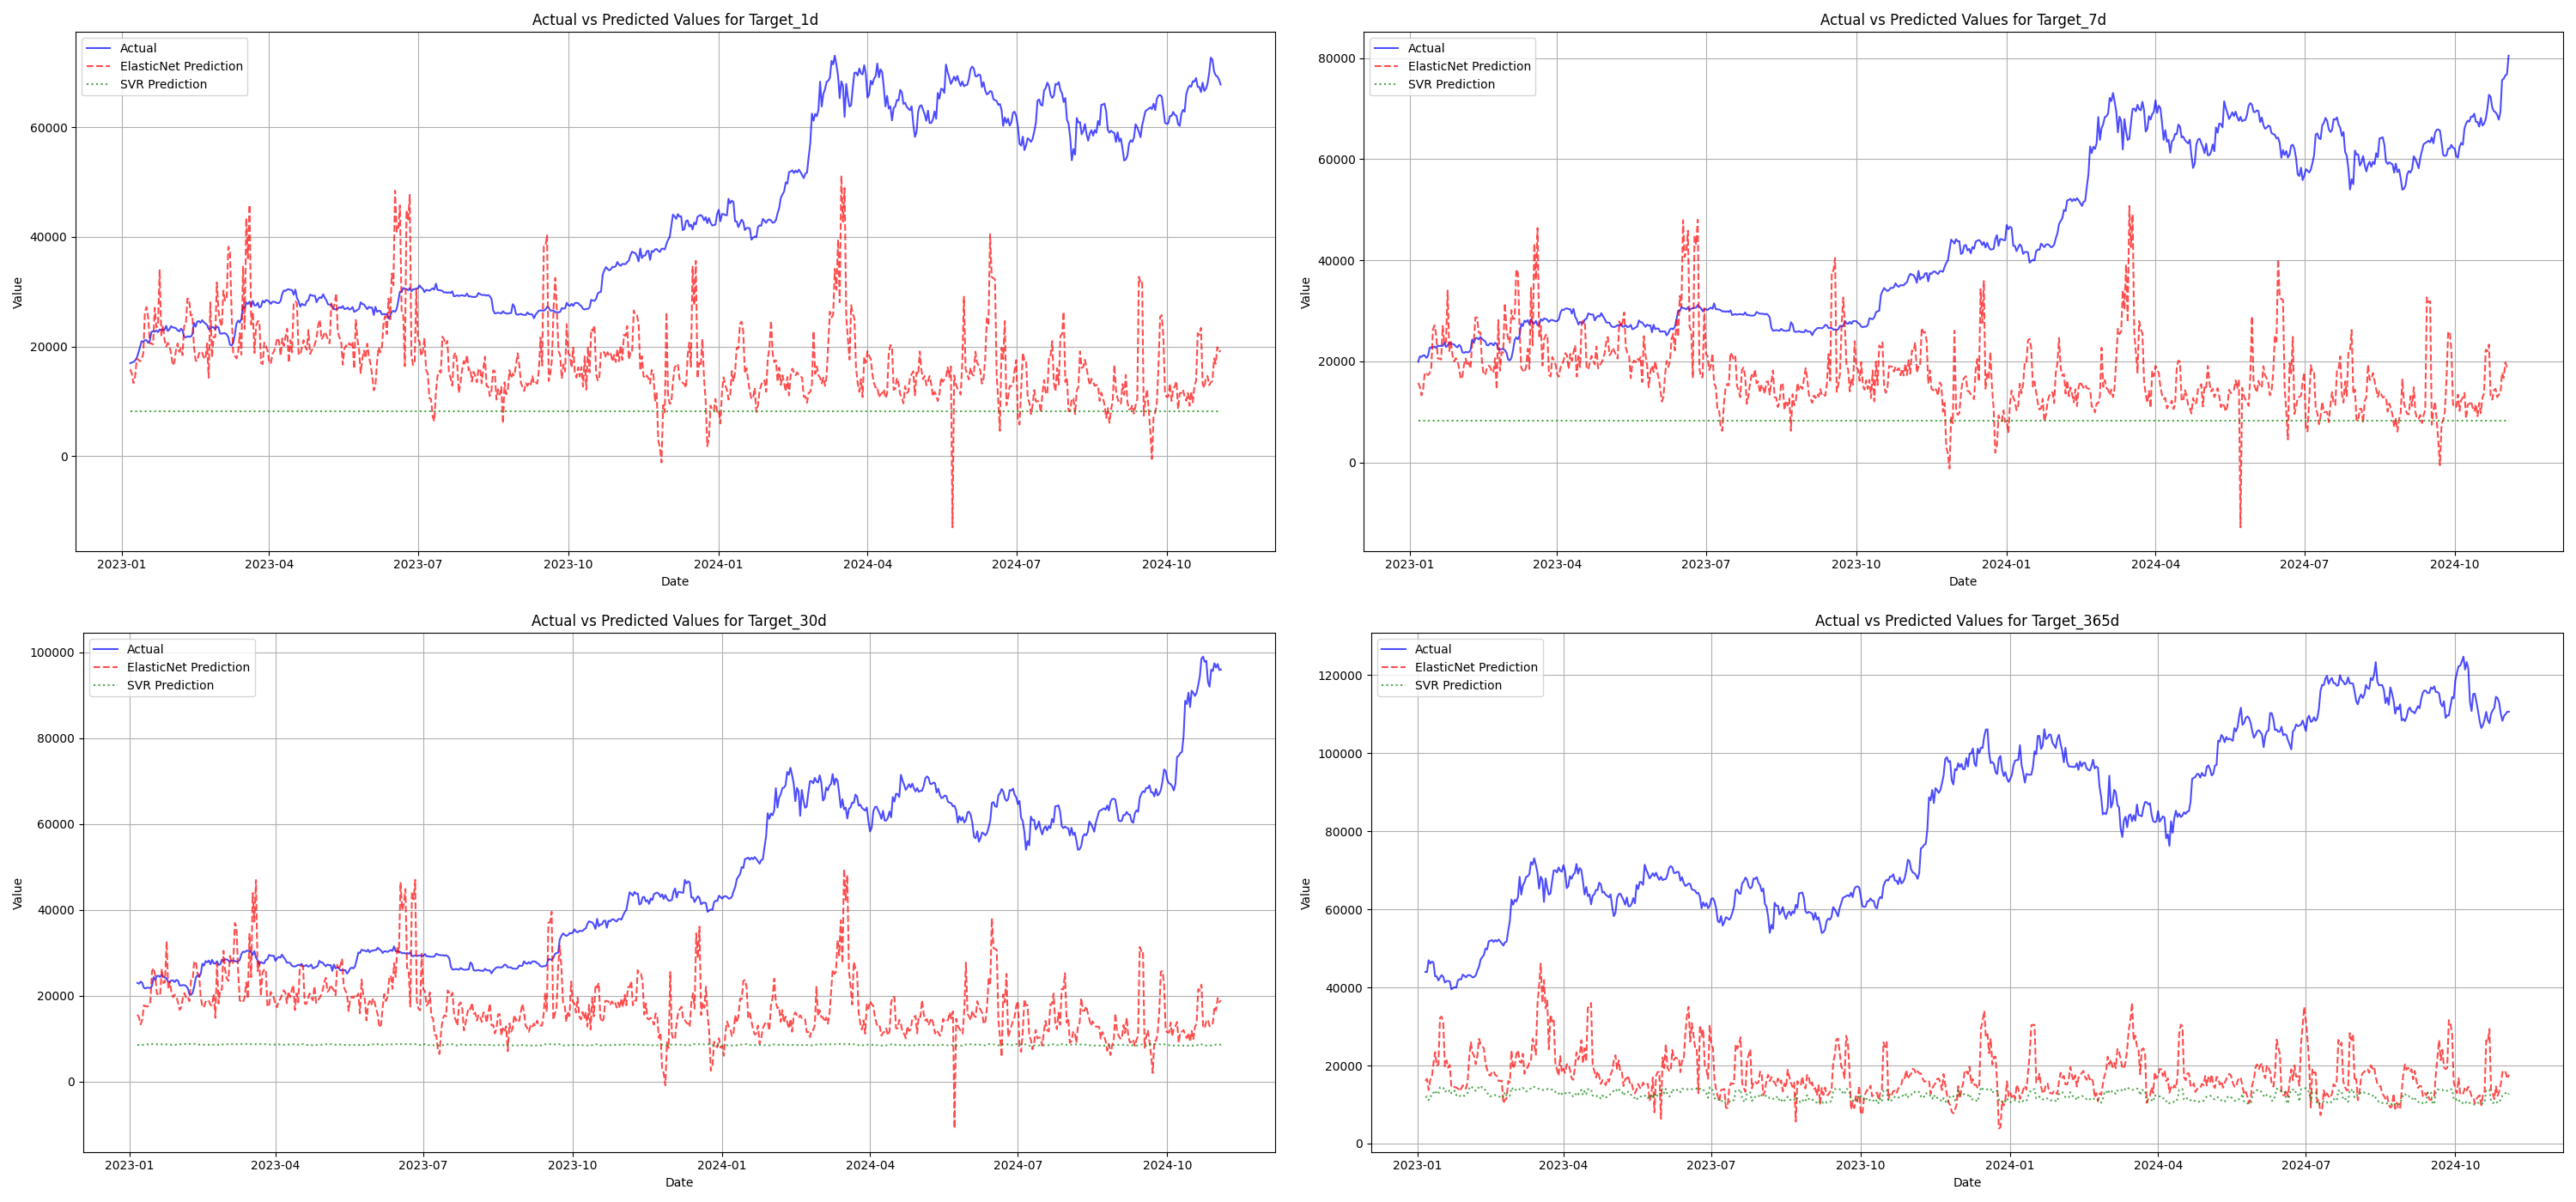

In [20]:
if loaded_images:
    # 1. Determine the maximum width and height among the loaded images
    widths, heights = zip(*(i.size for i in loaded_images))
    max_width = max(widths)
    max_height = max(heights)

    # Calculate dimensions for a 2x2 grid
    # The combined image will have 2 images horizontally and 2 images vertically
    combined_width = max_width * 2
    combined_height = max_height * 2

    # 2. Create a new blank image with the calculated dimensions
    # Using RGBA for transparency, then converting to RGB if needed for saving as JPG, but PNG is fine.
    combined_image = Image.new('RGB', (combined_width, combined_height), (255, 255, 255)) # White background

    # 3. Paste each loaded image onto the canvas in a 2x2 grid layout
    # Arrangement:
    # [0] [1]
    # [2] [3]

    # Top-left
    combined_image.paste(loaded_images[0], (0, 0))
    # Top-right
    combined_image.paste(loaded_images[1], (max_width, 0))
    # Bottom-left
    combined_image.paste(loaded_images[2], (0, max_height))
    # Bottom-right
    combined_image.paste(loaded_images[3], (max_width, max_height))

    # Define the save path for the combined image
    combined_plot_path = 'plots_advanced_eset/combined_predictions.png'

    # 4. Save the combined image
    combined_image.save(combined_plot_path)
    print(f"Combined plot saved to: {combined_plot_path}")

    # Display the combined image (optional)
    from IPython.display import display
    print("Displaying combined plot:")
    display(combined_image)
else:
    print("No images were loaded to combine.")

## Final Task

### Subtask:
Confirm that all prediction plots have been successfully combined and displayed in a single image.


## Summary:

### Q&A
Yes, all four prediction plots were successfully combined into a single image, saved as `plots_advanced_eset/combined_predictions.png`, and then displayed.

### Data Analysis Key Findings
*   The `Pillow` library, essential for image manipulation, was confirmed to be installed.
*   All four specified prediction plot images (`Target_1d_predictions.png`, `Target_7d_predictions.png`, `Target_30d_predictions.png`, and `Target_365d_predictions.png`) were successfully loaded from the `plots_advanced_eset` directory.
*   The loaded images were successfully combined into a single image, arranged in a 2x2 grid, with a resolution of 3000x1400 pixels.
*   The combined image was saved as `plots_advanced_eset/combined_predictions.png` and subsequently displayed.

### Insights or Next Steps
*   The combined image provides a consolidated view of predictions across various time horizons (1-day, 7-day, 30-day, and 365-day), which is crucial for a quick comparative analysis of forecast performance over different periods.
*   This combined visualization can be easily shared with stakeholders to communicate the full spectrum of prediction results effectively.


# Task
Load the individual prediction CSV files from the 'results' directory, combine them into a single DataFrame based on the 'Date' column while renaming columns to prevent conflicts, save the combined DataFrame to 'results/combined_predictions_all_targets.csv', and display the head of the combined CSV to verify its content and structure.

## Load Individual Prediction CSVs

### Subtask:
Load the individual prediction CSV files (predictions_Target_1d.csv, predictions_Target_7d.csv, predictions_Target_30d.csv, predictions_Target_365d.csv) from the 'results' directory into separate pandas DataFrames.


**Reasoning**:
To load the individual prediction CSV files, I will iterate through the defined targets, construct the file path for each, read the CSV into a DataFrame, convert the 'Date' column to datetime objects, and store the resulting DataFrames in a dictionary.



In [21]:
predictions_dataframes = {}

for target_name in targets:
    predictions_file = f'results/predictions_{target_name}.csv'
    if os.path.exists(predictions_file):
        df_predictions = pd.read_csv(predictions_file)
        df_predictions['Date'] = pd.to_datetime(df_predictions['Date'])
        predictions_dataframes[target_name] = df_predictions
        print(f"Loaded {target_name} predictions into DataFrame.")
    else:
        print(f"Prediction file not found for {target_name}: {predictions_file}")

print("All prediction CSVs loaded successfully into 'predictions_dataframes' dictionary.")

Loaded Target_1d predictions into DataFrame.
Loaded Target_7d predictions into DataFrame.
Loaded Target_30d predictions into DataFrame.
Loaded Target_365d predictions into DataFrame.
All prediction CSVs loaded successfully into 'predictions_dataframes' dictionary.


In [22]:
combined_df = None

for target_name, df_pred in predictions_dataframes.items():
    # Rename columns to avoid conflicts when merging, except for 'Date'
    renamed_df = df_pred.rename(columns={
        'Actual': f'Actual_{target_name}',
        'ElasticNet_Prediction': f'ElasticNet_Prediction_{target_name}',
        'SVR_Prediction': f'SVR_Prediction_{target_name}'
    })

    if combined_df is None:
        combined_df = renamed_df
    else:
        # Merge on 'Date' column
        combined_df = pd.merge(combined_df, renamed_df, on='Date', how='outer')

# Sort by Date to ensure chronological order
combined_df = combined_df.sort_values('Date').reset_index(drop=True)

# Define the path for the combined CSV file
combined_csv_path = 'results/combined_predictions_all_targets.csv'

# Save the combined DataFrame to a CSV file
combined_df.to_csv(combined_csv_path, index=False)
print(f"Combined predictions saved to: {combined_csv_path}")

# Display the head of the combined DataFrame
print("\nHead of the combined DataFrame:")
print(combined_df.head())

Combined predictions saved to: results/combined_predictions_all_targets.csv

Head of the combined DataFrame:
        Date  Actual_Target_1d  ElasticNet_Prediction_Target_1d  \
0 2023-01-06      16955.078125                     15853.044692   
1 2023-01-07      17091.144531                     15031.780796   
2 2023-01-08      17196.554688                     13332.182366   
3 2023-01-09      17446.292969                     14531.721018   
4 2023-01-10      17934.896484                     17776.302002   

   SVR_Prediction_Target_1d  Actual_Target_7d  \
0               8249.074707      19909.574219   
1               8249.074707      20976.298828   
2               8249.074707      20880.798828   
3               8249.074707      21169.632812   
4               8249.074707      21161.519531   

   ElasticNet_Prediction_Target_7d  SVR_Prediction_Target_7d  \
0                     15751.225819               8268.100342   
1                     14973.936698               8268.100342   
2

In [23]:
# MAPE hesaplamak için fonksiyon (Görselde MAPE de var)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 1. Boş bir liste oluşturuyoruz
final_report_list = []

# 2. Döngü ile sonuçları listeye ekliyoruz
for target_name, models in all_results.items():
    for model_name, metrics in models.items():
        # MAPE hesaplamasını burada yapalım (Eğer yukarıda kaydetmediysen)
        # Tahminleri CSV'den veya hafızadan çekip MAPE hesaplatıyoruz
        row = {
            'Target': target_name,
            'Model': model_name,
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE'],
            'R2': metrics['R2'],
            'Num_Features': X_train.shape[1], # Özellik sayısı
            'Best_Params': str(metrics['Best_Params'])
        }
        final_report_list.append(row)

# 3. Listeyi DataFrame'e dönüştür
results_df = pd.DataFrame(final_report_list)

# 4. Google Colab'da tabloyu göster
from google.colab import data_table
display(data_table.DataTable(results_df, include_index=False, num_rows_per_page=10))

# 5. Sonucu CSV olarak kaydet (Görseldeki gibi bir dosya oluşturur)
results_df.to_csv('results/results_advanced_eset.csv', index=False)
print("\nSonuçlar 'results/results_advanced_eset.csv' olarak kaydedildi.")

,Target,Model,RMSE,MAE,R2,Num_Features,Best_Params
0,Target_1d,ElasticNet,33486.750767,27381.143898,-2.737033,119,"{'alpha': 10.0, 'l1_ratio': 0.9}"
1,Target_1d,SVR,39480.029749,35476.825166,-4.194405,119,"{'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}"
2,Target_7d,ElasticNet,33958.890027,27748.352986,-2.806221,119,"{'alpha': 10.0, 'l1_ratio': 0.9}"
3,Target_7d,SVR,39969.744649,35980.566712,-4.272903,119,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}"
4,Target_30d,ElasticNet,36832.890475,30030.582663,-2.713754,119,"{'alpha': 10.0, 'l1_ratio': 0.9}"
5,Target_30d,SVR,42708.131450,38178.610860,-3.993013,119,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}"
6,Target_365d,ElasticNet,70102.549486,65686.651312,-8.423630,119,"{'alpha': 10.0, 'l1_ratio': 0.9}"
7,Target_365d,SVR,74867.963454,71180.588946,-9.748371,119,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}"



Sonuçlar 'results/results_advanced_eset.csv' olarak kaydedildi.
